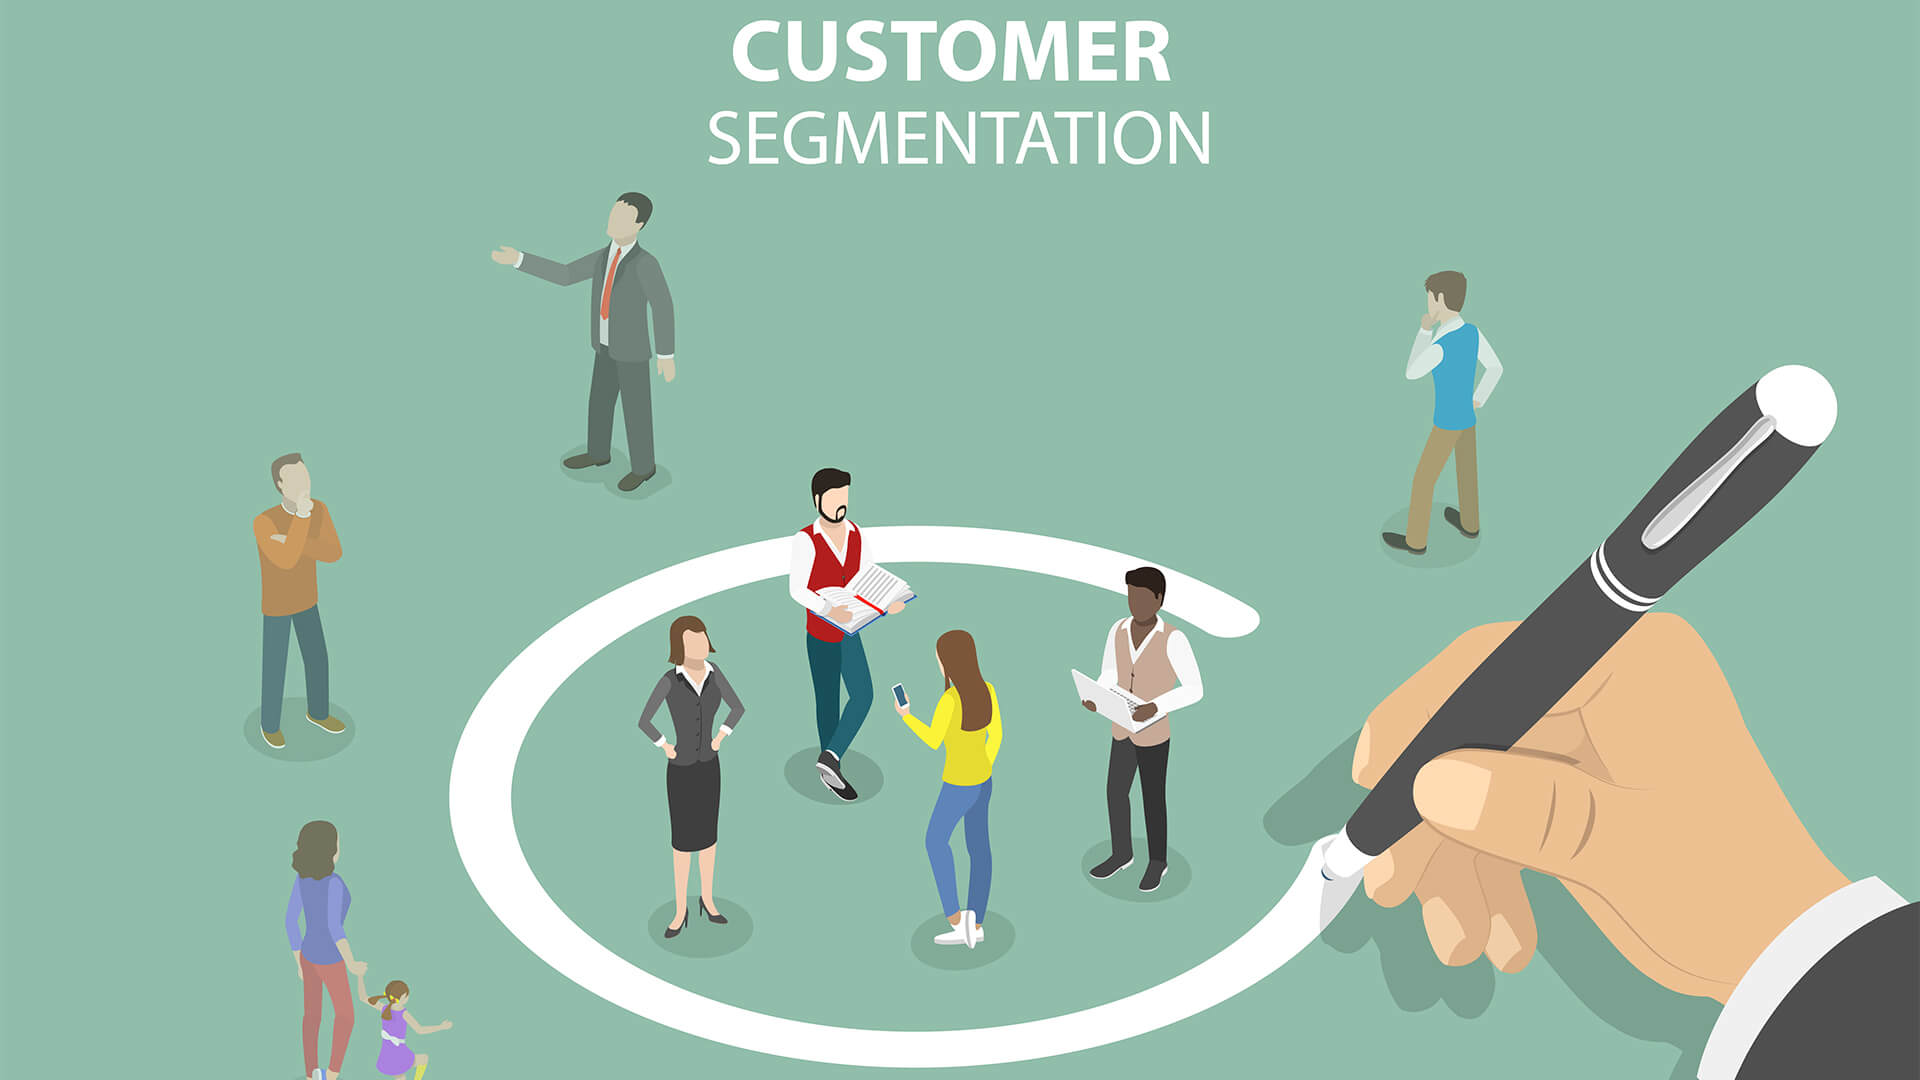

# **Phase 2: Segmentation and Business Retention Recommendations**

**Goal:** Engineer customer-level behavioral features, evaluate clustering feasibility, and design interpretable, actionable customer segments.

In this phase, I build a customer-level feature table from transactional data and develop actionable customer segments. The goal is to understand how customers differ in purchasing behavior, identify high-value groups, and design targeted marketing strategies. I first engineer core behavioral features, test unsupervised clustering approaches, and ultimately construct interpretable RFM-based segments aligned with business use cases.

In [1]:
#Import the libraries
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer


In [2]:
#Load the Clean Data after EDA
clean_data = pd.read_csv("/content/sample_data/cleaned_data.csv")

In [3]:
#basic information about Dataframe
display(clean_data)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
392687,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
392688,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
392689,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
392690,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


**# FEATURE ENGINEERING & PRE-PROCESSING:**

Our first step is to build the tables we need to perform our Segmentation. Using the clean dataset from Phase 1, we will create a customer-level feature table containing the core RFM metrics recency, frequency, and monetary value, as well as other lifecycle metrics such as first purchase, last purchase date, active lifespan, and average interpurchase gap.

In [4]:
#Calculating Revenue and adding a column for it
clean_data["Revenue"] = (
    clean_data["Quantity"] *
    clean_data["UnitPrice"]
)
display(clean_data)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
392687,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
392688,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
392689,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
392690,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [5]:
clean_data["InvoiceDate"] = pd.to_datetime(clean_data["InvoiceDate"])
reference_date = clean_data["InvoiceDate"].max() + pd.Timedelta(days=1)

# ** Adding addional features**

*   **Column**	          - **Meaning**
*   CustomerID            - Customer ID
*   first_purchase_date	  - First order date
*   last_purchase_date	  - Last order date
*   recency_days	Days    - since last purchase
*   frequency_orders	    - Number of orders
*   monetary_total	      - Total revenue
*   aov	                  - Average order value
*   active_lifespan_days	- Customer lifespan(Active ib shoping)
*   interpurchase_gap	    - Average gap between purchases
*   avg_items_per_order	  - Average basket size
*   avg_unit_price	      - Average price paid per item

In [6]:
#Customer Feature Table
customer_features = (
    clean_data
    .groupby("CustomerID")
    .agg(
        first_purchase_date=("InvoiceDate", "min"),
        last_purchase_date=("InvoiceDate", "max"),
        frequency_orders=("InvoiceNo", "nunique"),
        monetary_total=("Revenue", "sum"),
        total_quantity=("Quantity", "sum")
    )
    .reset_index()
)
display(customer_features)

,CustomerID,first_purchase_date,last_purchase_date,frequency_orders,monetary_total,total_quantity
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,2458
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,2341
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197
...,...,...,...,...,...,...
4333,18280.0,2011-03-07 09:52:00,2011-03-07 09:52:00,1,180.60,45
4334,18281.0,2011-06-12 10:53:00,2011-06-12 10:53:00,1,80.82,54
4335,18282.0,2011-08-05 13:35:00,2011-12-02 11:43:00,2,178.05,103
4336,18283.0,2011-01-06 14:14:00,2011-12-06 12:02:00,16,2045.53,1357


In [7]:
#Calculating Recency
customer_features["recency_days"] = (
    reference_date
    - customer_features["last_purchase_date"]
).dt.days
display(customer_features.head())

,CustomerID,first_purchase_date,last_purchase_date,frequency_orders,monetary_total,total_quantity,recency_days
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,326
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,2458,2
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,2341,75
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,19
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,310


In [8]:
#Calculating Average order value
customer_features["aov"] = (
    customer_features["monetary_total"]
    / customer_features["frequency_orders"]
)

In [9]:
#Calculating customer active days in shopping called - active lifespan days
customer_features["active_lifespan_days"] = (
    customer_features["last_purchase_date"]
    - customer_features["first_purchase_date"]
).dt.days

In [10]:
#Calculating Average items per order
customer_features["avg_items_per_order"] = (
    customer_features["total_quantity"]
    / customer_features["frequency_orders"]
)

In [11]:
#Calculating Average Unit Price
customer_features["avg_unit_price"] = (
    customer_features["monetary_total"]
    / customer_features["total_quantity"]
)

In [12]:
#Final Customer Features DataFrame
# Reorder columns
customer_features = customer_features[
    [
        "CustomerID",
        "first_purchase_date",
        "last_purchase_date",
        "recency_days",
        "frequency_orders",
        "monetary_total",
        "aov",
        "active_lifespan_days",
        "avg_items_per_order",
        "avg_unit_price"
    ]
]
display(customer_features.head())

,CustomerID,first_purchase_date,last_purchase_date,recency_days,frequency_orders,monetary_total,aov,active_lifespan_days,avg_items_per_order,avg_unit_price
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,326,1,77183.60,77183.600000,0,74215.000000,1.040000
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,2,7,4310.00,615.714286,365,351.142857,1.753458
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,75,4,1797.24,449.310000,282,585.250000,0.767723
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,19,1,1757.55,1757.550000,0,631.000000,2.785341
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,310,1,334.40,334.400000,0,197.000000,1.697462


# **Part B: Segmentation with K-Means Clustering**

Transform and Scale Variables
We will use the clustering drivers:

recency_days
frequency_orders
monetary_total
interpurchase_gap
Since we will be performing K-means on our repeat customers, we need to filter to customers who made more than one purchase, that is frequency_orders greater than or equal to 2.

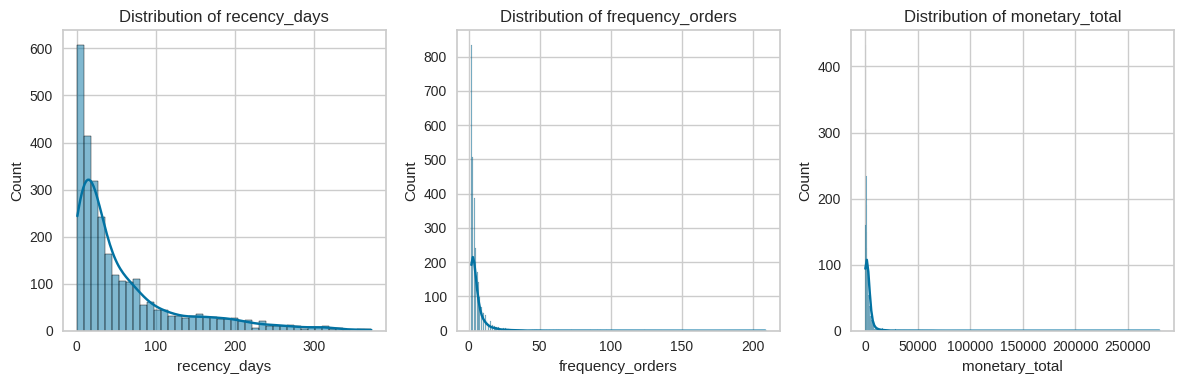

In [13]:
# filter repeat customers
filtered_customers = customer_features[
    customer_features['frequency_orders'] >= 2
].copy()

cluster_feats = [
    'recency_days',
    'frequency_orders',
    'monetary_total'
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, cluster_feats):
    sns.histplot(filtered_customers[col], ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

**Insights:**

From the above plots, we notice that the monetary_total and frequency_orders are highly skewed to the right with extreme maximum values. Thus, we need to apply log transformations to prevent outliers from dominating during clustering.

In [14]:
#SCALING THE DATA

# work on a clean copy ONLY
df = filtered_customers.copy()

# -----------------------------
# Step 1: define features
# -----------------------------
cluster_feats = [
    'recency_days',
    'frequency_orders',
    'monetary_total'
]

# -----------------------------
# Step 2: Winsorization (cap outliers)
# -----------------------------
LOW_Q, HIGH_Q = 0.01, 0.99

cap_bounds = {}

for col in cluster_feats:
    lo = df[col].quantile(LOW_Q)
    hi = df[col].quantile(HIGH_Q)

    cap_bounds[col] = (lo, hi)
    df[col] = df[col].clip(lower=lo, upper=hi)

# -----------------------------
# Step 3: Log transform (skewed features only)
# -----------------------------
log_cols = ['frequency_orders', 'monetary_total']

for col in log_cols:
    df[col] = np.log1p(df[col])

# -----------------------------
# Step 4: Scaling
# -----------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[cluster_feats])

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=cluster_feats,
    index=df.index
)

X_scaled_df = pd.concat(
    [df[['CustomerID']].reset_index(drop=True),
     X_scaled_df.reset_index(drop=True)],
    axis=1
)

display(X_scaled_df.head())

,CustomerID,recency_days,frequency_orders,monetary_total
0,12347.0,-0.817357,0.672130,1.176517
1,12348.0,0.236182,-0.125053,0.343479
2,12352.0,-0.326668,0.871904,0.660069
3,12356.0,-0.514284,-0.503531,0.769582
4,12358.0,-0.817357,-0.991475,-0.066779


# Now Our Data is ready for Modeling


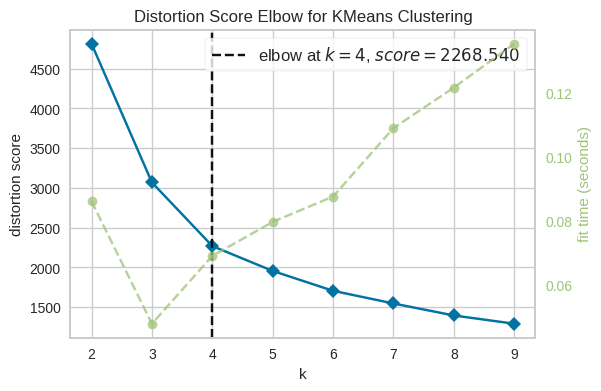

Optimal number of clusters: 4


In [15]:
# use elbow method to find optimal number of clusters

X_input = X_scaled  # numpy array from scaler step

plt.figure(figsize=(6,4))

model = KMeans(
    random_state=42,
    n_init=10
)

visualizer = KElbowVisualizer(
    model,
    k=(2, 10),
    metric='distortion'
)

visualizer.fit(X_input)
visualizer.show()

print("Optimal number of clusters:", visualizer.elbow_value_)

In [16]:
# fit k-means
kmeans = KMeans(n_clusters = 4, random_state = 42)
filtered_customers['cluster'] = kmeans.fit_predict(X_scaled_df[cluster_feats])

# segment profiling table to view characteristics of each cluster
filtered_customers.groupby('cluster').agg(
    customers = ('CustomerID', 'nunique'),
    recency_median=('recency_days', 'median'),
    frequency_median=('frequency_orders', 'median'),
    monetary_median=('monetary_total', 'median'),
    monetary_min=('monetary_total', 'min'),
    monetary_max=('monetary_total', 'max'),
    aov_median=('aov', 'median'),
    lifespan_median=('active_lifespan_days', 'median'),
    avg_items_per_order_median =('avg_items_per_order', 'median'),
    avg_unit_price_median=('avg_unit_price', 'median')
)

,customers,recency_median,frequency_median,monetary_median,monetary_min,monetary_max,aov_median,lifespan_median,avg_items_per_order_median,avg_unit_price_median
cluster,,,,,,,,,,
0,412,191.0,2.0,592.97,52.00,44534.30,230.812500,84.5,122.166667,1.957379
1,361,8.0,15.0,5891.61,1296.44,280206.02,399.387143,350.0,227.760000,1.848953
2,1078,33.0,2.0,646.36,6.90,2225.37,233.531667,158.0,135.000000,1.765478
3,994,22.0,5.0,1977.36,621.68,168472.50,352.779286,258.0,216.312500,1.768023


# **PCA Analysis:**

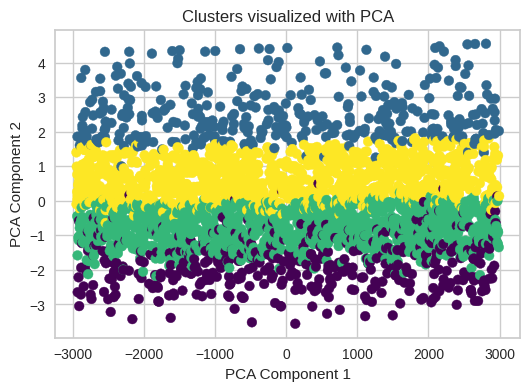

Silhouette Score: -0.028


In [17]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled_df)

# plot
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=filtered_customers['cluster'], cmap='viridis')
plt.title("Clusters visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# evaluate model using silhouette score
score = silhouette_score(X_scaled_df, filtered_customers['cluster'])
print(f"Silhouette Score: {score:.3f}")

**INSIGHTS:**

The silhouette score is -0.028(Negative) and the PCA plot shows clusters heavily overlapping, that's strong evidence that K-Means is not finding meaningful customer segments with those features. we conclude that KMeans clustering is not suitable for this dataset, meaning there is no clear natural separation in behavioral space. This suggests that purchasing behavior in this dataset exists along continuous gradients rather than forming distinct, well-defined cluster groups. Therefore, a business-rule segmentation is more appropriate.

# **Part C: Business-Driven RFM Segmentation**



*   Since natural clusters were weak after transformation, I pivoted to an
RFM-based rule segmentation to produce stable and interpretable business segments.
*   To begin our RFM analysis, we will score customers based on each attribute--Recency, Frequency, and Monetary Total--a value from 1 to 5.

*   We will first rank customers based on recency, that is, how recently a customer made a purchase. Individuals with more recent purchases are given higher scores. So, a higher recency_days value is given a lower score on the 1-5 scale.

*  We then rank customers based on frequency, how often they make a purchase. The more frequent the purchases, the higher the score.

*   Lastly, we rank customers by monetary total with the highest spenders getting scored a value of 5 and the lowest spenders getting a score of 1.













In [18]:
rfm = customer_features.copy()

# scoring
# create 5 bins for each attribute
r_bins = min(rfm['recency_days'].nunique(), 5)
f_bins = min(rfm['frequency_orders'].nunique(), 5)
m_bins = min(rfm['monetary_total'].nunique(), 5)

# bin each col into quantiles and assign scores
# lower recency_days corresponds to more recent purchase --> higher recency score
rfm['r_score'] = pd.qcut(rfm['recency_days'], q = r_bins, labels = list(range(r_bins, 0, -1)), duplicates = 'drop').astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency_orders'].rank(method = 'first'), q = f_bins, labels = list(range(1, f_bins + 1)), duplicates = 'drop').astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary_total'].rank(method = 'first'), q = m_bins, labels = list(range(1, m_bins + 1)), duplicates = 'drop').astype(int)

rfm.head()

,CustomerID,first_purchase_date,last_purchase_date,recency_days,frequency_orders,monetary_total,aov,active_lifespan_days,avg_items_per_order,avg_unit_price,r_score,f_score,m_score
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,326,1,77183.60,77183.600000,0,74215.000000,1.040000,1,1,5
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,2,7,4310.00,615.714286,365,351.142857,1.753458,5,5,5
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,75,4,1797.24,449.310000,282,585.250000,0.767723,2,4,4
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,19,1,1757.55,1757.550000,0,631.000000,2.785341,4,1,4
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,310,1,334.40,334.400000,0,197.000000,1.697462,1,1,2


We will segment our customers into 10 categories:

*   **Champions:** customers with the highest recency and frequency scores
*   **Loyal Users:** customers with the highest frequency of interactions and strong recency scores
*   **Potential Loyalists:** customers with recent purchases who demonstrate potential to convert to Champions or Loyal Users
*   **New Users:** most recent customers with low frequency
*   **Promising Users:** customers with strong recency and potential to become high-frequency users
*   **Needing Attention:** customers with moderate recency and frequency but drifting engagement
*   **About to Sleep:** customers with below-average recency and frequency scores that have the potential to slip away without engagement
*   **At Risk:** once frequent customers with low recency
Cannot Lose Them: once active customers without recent engagement
*   **Hibernating:** customers with the lowest recency and frequency scores that may be lost permanently.

In [19]:
#Segregating Customers

conditions = [
    # Champions
    (rfm['r_score'] >= 4) & (rfm['f_score'] >= 4) & (rfm['m_score'] >= 4),

    # Loyal Customers
    (rfm['f_score'] >= 4) & (rfm['r_score'].between(2, 3)),

    # Potential Loyalists
    (rfm['r_score'] >= 4) & (rfm['f_score'].between(2, 3)),

    # New Customers
    (rfm['r_score'] == 5) & (rfm['f_score'] <= 2),

    # Promising
    (rfm['r_score'] == 4) & (rfm['f_score'] == 1),

    # Need Attention
    (rfm['r_score'] == 3) & (rfm['f_score'] <= 2),

    # About to Sleep
    (rfm['r_score'] == 2) & (rfm['f_score'] <= 2),

    # At Risk
    (rfm['r_score'].between(2, 3)) & (rfm['f_score'] >= 3),

    # Cannot Lose Them
    (rfm['r_score'] == 1) & (rfm['f_score'] >= 3),

    # Hibernating
    (rfm['r_score'] == 1) & (rfm['f_score'] <= 2)
]

categories = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'New Customers',
    'Promising',
    'Need Attention',
    'About to Sleep',
    'At Risk',
    'Cannot Lose Them',
    'Hibernating'
]

rfm['segment'] = np.select(conditions, categories, default='Unclassified')

In [20]:
# ----------------------------
# Segment size distribution
# ----------------------------
segment_sizes = (
    rfm['segment']
    .value_counts()
    .rename_axis('segment')
    .reset_index(name='customers')
)

segment_sizes['pct_customers'] = (
    segment_sizes['customers'] / segment_sizes['customers'].sum()
)

display(segment_sizes)


# ----------------------------
# Segment profiling
# ----------------------------
profile = (
    rfm.groupby('segment')
    .agg(
        customers=('CustomerID', 'count'),

        # core RFM metrics ONLY
        recency_median=('recency_days', 'median'),
        frequency_median=('frequency_orders', 'median'),
        monetary_median=('monetary_total', 'median'),

        # optional business metrics (keep but interpret carefully)
        aov_median=('aov', 'median'),
        lifespan_median=('active_lifespan_days', 'median')
    )
    .reset_index()
)

display(profile)

,segment,customers,pct_customers
0,Champions,957,0.220609
1,Hibernating,664,0.153066
2,Loyal Customers,537,0.123790
3,Potential Loyalists,492,0.113416
4,At Risk,412,0.094975
5,About to Sleep,401,0.092439
6,Need Attention,351,0.080913
7,Cannot Lose Them,201,0.046335
8,Unclassified,182,0.041955
9,Promising,99,0.022822


,segment,customers,recency_median,frequency_median,monetary_median,aov_median,lifespan_median
0,About to Sleep,401,114.0,1.0,329.650,304.560000,0.0
1,At Risk,412,78.0,2.0,636.325,291.245000,140.0
2,Cannot Lose Them,201,221.0,2.0,542.030,207.760000,70.0
3,Champions,957,10.0,7.0,2633.850,352.214167,313.0
4,Hibernating,664,274.0,1.0,246.715,236.030000,0.0
5,Loyal Customers,537,64.0,4.0,1462.720,311.636667,227.0
6,Need Attention,351,53.0,1.0,326.240,307.780000,0.0
7,New Customers,42,7.0,1.0,274.505,274.505000,0.0
8,Potential Loyalists,492,18.0,2.0,512.180,262.560833,66.5
9,Promising,99,23.0,1.0,223.850,223.850000,0.0


The RFM segmentation clearly groups customers based on their purchasing behavior across recency, frequency, and monetary value. Champions represent the most valuable segment, with very recent purchases, high frequency, and the highest spending. In contrast, Hibernating customers show long inactivity, low purchase frequency, and minimal monetary contribution, indicating disengagement. Segments such as Potential Loyalists and At Risk customers fall in between, reflecting varying levels of engagement and churn risk. Overall, the segmentation produces clear, interpretable customer groups that can be directly used for targeted marketing and retention strategies.

# **Visualize Segment Distribution**

I visualize segment sizes to understand population balance across behavioral groups. This highlights the relative proportion of high-value versus low-engagement customers and provides insight into where marketing resources may yield the greatest return.

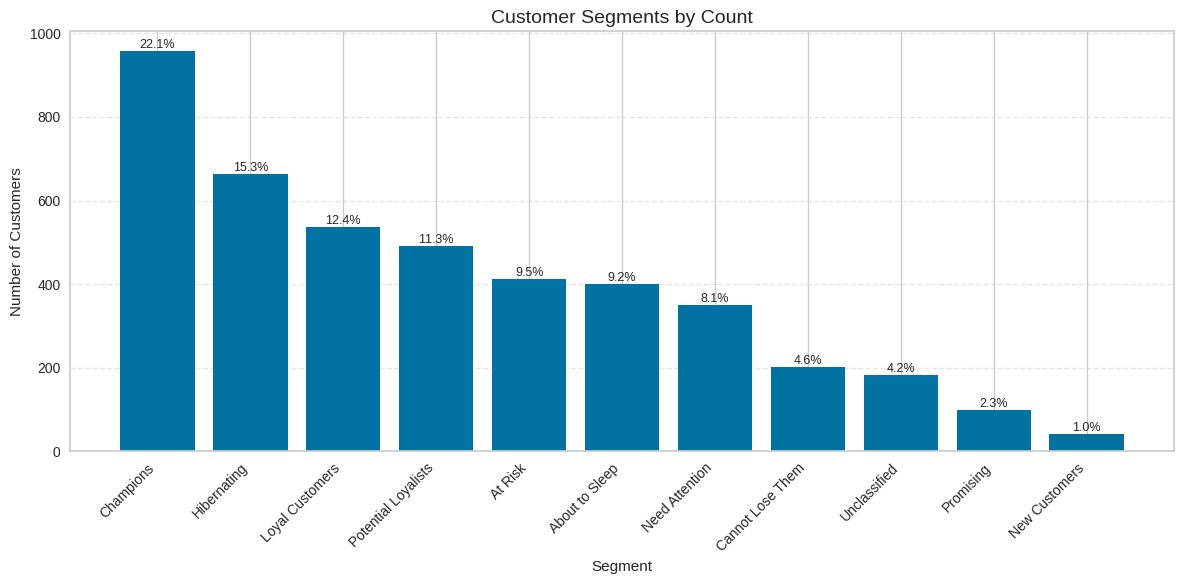

In [21]:
# sort segments for better readability
plot_data = profile.sort_values('customers', ascending=False).copy()

# compute percentage share
plot_data['pct'] = plot_data['customers'] / plot_data['customers'].sum() * 100

plt.figure(figsize=(12,6))
bars = plt.bar(plot_data['segment'], plot_data['customers'])

plt.title('Customer Segments by Count', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# add percentage labels on top of bars
for bar, pct in zip(bars, plot_data['pct']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Insights:**

The bar chart illustrates the distribution of customers across different RFM-based segments. It is observed that the largest groups include high-volume segments such as Champions, Hibernating, and At Risk customers, indicating a strong polarization in customer behavior between highly active and inactive users. Champions represent a valuable group of highly engaged and high-spending customers, while Hibernating customers form a significant inactive base with minimal recent interaction. Intermediate segments such as Potential Loyalists and Loyal Customers highlight customers with moderate engagement and conversion potential. The inclusion of percentage distribution further clarifies the proportional contribution of each segment, providing a clearer understanding of customer composition for targeted marketing strategies.

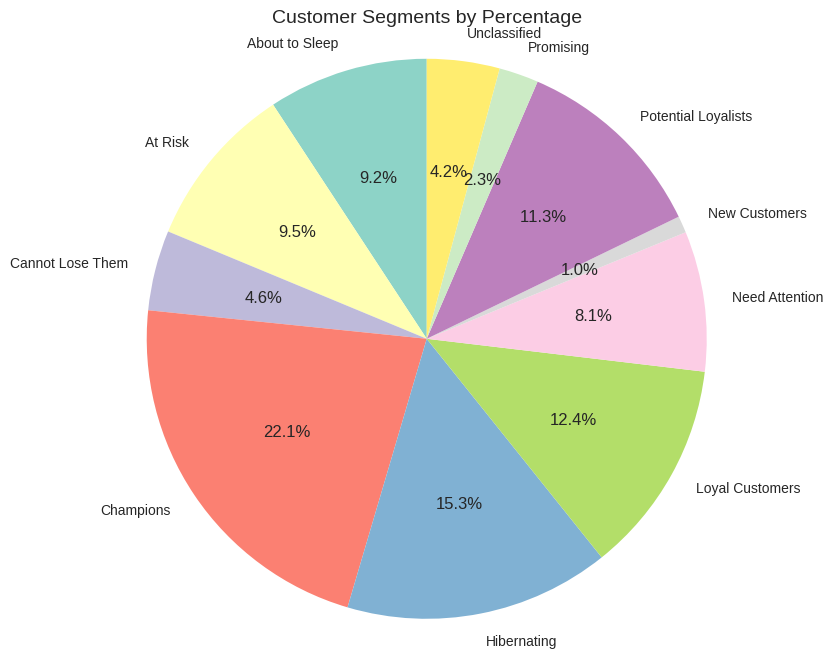

In [22]:
# pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(profile)))

plt.figure(figsize=(10,8))

plt.pie(
    profile['customers'],
    labels=profile['segment'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Segments by Percentage', fontsize=14)
plt.axis('equal')
plt.show()

# **Revenue Contribution by Segment:**
Which segments drive revenue?

In [23]:
# group by segment and calculate total revenue of each group
revenue_overview = pd.DataFrame(rfm.groupby('segment')['monetary_total'].agg('sum'))

# calculate total revenue across all groups
total_rev = revenue_overview['monetary_total'].sum()

# calculate each group's percentage of total revenue
revenue_overview['percent_of_total_rev'] = (revenue_overview['monetary_total'] / total_rev)

# sort highest to lowest percentage to find biggest drivers
revenue_overview = revenue_overview.sort_values('percent_of_total_rev', ascending = False)

# formatting
revenue_overview.columns = ['Revenue', 'Percent of Total Revenue']
revenue_overview['Percent of Total Revenue'] = revenue_overview['Percent of Total Revenue'].map('{:.2%}'.format)

display(revenue_overview)

,Revenue,Percent of Total Revenue
segment,,
Champions,5791640.740,65.17%
Loyal Customers,1134604.440,12.77%
Potential Loyalists,506813.630,5.70%
At Risk,359496.921,4.05%
Hibernating,315459.971,3.55%
Cannot Lose Them,242289.920,2.73%
About to Sleep,202862.181,2.28%
Need Attention,161108.110,1.81%
Unclassified,121781.341,1.37%


# **SIMPLE SALE FORECAST:**

In [24]:
#Prepare Data
clean_data['InvoiceDate'] = pd.to_datetime(clean_data['InvoiceDate'])

clean_data['Month'] = clean_data['InvoiceDate'].dt.to_period('M')

monthly_sales = clean_data.groupby('Month')['Revenue'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

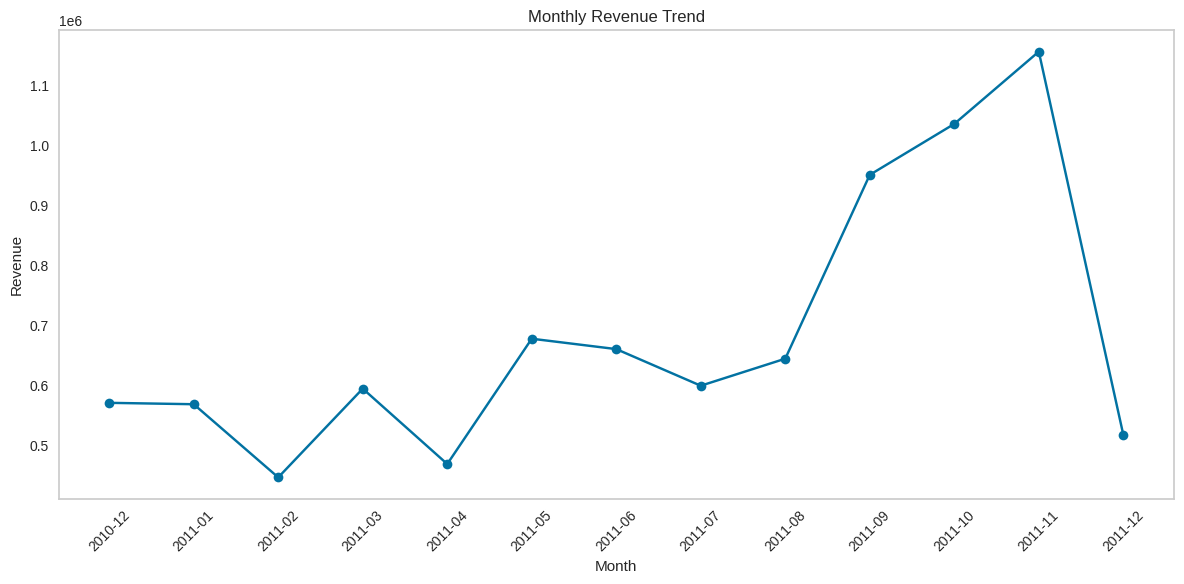

In [25]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Month'],
    monthly_sales['Revenue'],
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()

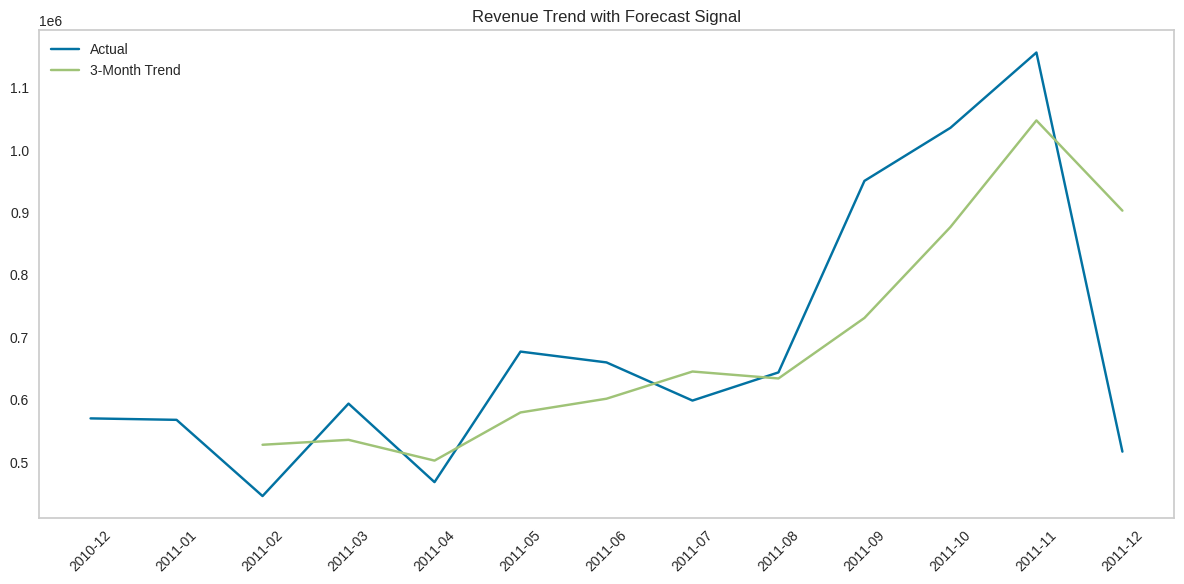

In [26]:
monthly_sales['RollingMean'] = monthly_sales['Revenue'].rolling(window=3).mean()

plt.figure(figsize=(12,6))

plt.plot(monthly_sales['Month'], monthly_sales['Revenue'], label='Actual')
plt.plot(monthly_sales['Month'], monthly_sales['RollingMean'], label='3-Month Trend')

plt.title("Revenue Trend with Forecast Signal")
plt.legend()
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()

**HEAT MAP OF RFM SEGMENT PROFILE**

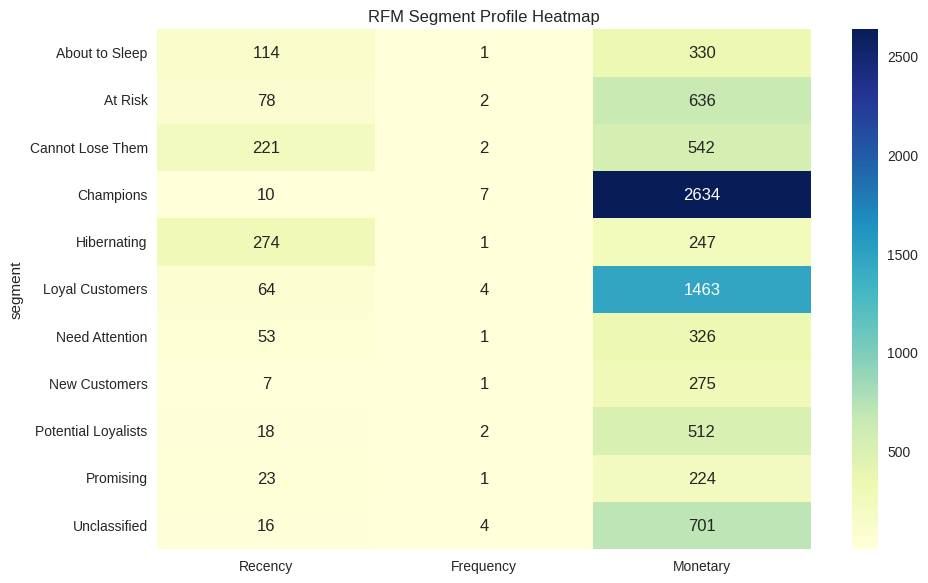

In [27]:
#Generating HeatMap
heatmap_data = (
    rfm.groupby('segment')
    .agg(
        Recency=('recency_days', 'median'),
        Frequency=('frequency_orders', 'median'),
        Monetary=('monetary_total', 'median')
    )
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('RFM Segment Profile Heatmap')
plt.tight_layout()
plt.show()

**INSIGHTS:**

Champions → low Recency, high Frequency, high Monetary

Hibernating → high Recency, low Frequency, low Monetary

Loyal Customers → moderate Recency, high Frequency

# **Customer Retention Strategy Matrix**

This matrix combines churn risk (from Logistic Regression) and RFM-based customer segments to define targeted retention strategies.

*   High-value customers (Champions, Loyal, Cannot Lose Them) require retention-first strategies rather than acquisition-focused marketing.
*   High churn-risk segments (At Risk, About to Sleep, Hibernating) require reactivation or cost-controlled engagement strategies.
*   Growth segments (Potential Loyalists, Promising) represent the highest ROI opportunity for conversion into Champions.

In [28]:
#Business Recommendation based on different customers segments

segment_actions = pd.DataFrame({
    'Segment': [
        'Champions',
        'Loyal Customers',
        'Potential Loyalists',
        'New Customers',
        'Promising',
        'Need Attention',
        'About to Sleep',
        'At Risk',
        'Cannot Lose Them',
        'Hibernating'
    ],
    'Recommended Action': [
        'Loyalty perks, VIP treatment',
        'Upsell bundles and cross-sell offers',
        'Nurture campaigns to build engagement',
        'Onboarding email sequence',
        'Incentivize second purchase with discounts',
        'Reminder emails and light incentives',
        'Reactivation discounts and limited-time offers',
        'Win-back campaigns with strong incentives',
        'Personal outreach and retention efforts',
        'Exclude from paid targeting / low-cost reactivation only'
    ]
})

display(segment_actions)

,Segment,Recommended Action
0,Champions,"Loyalty perks, VIP treatment"
1,Loyal Customers,Upsell bundles and cross-sell offers
2,Potential Loyalists,Nurture campaigns to build engagement
3,New Customers,Onboarding email sequence
4,Promising,Incentivize second purchase with discounts
5,Need Attention,Reminder emails and light incentives
6,About to Sleep,Reactivation discounts and limited-time offers
7,At Risk,Win-back campaigns with strong incentives
8,Cannot Lose Them,Personal outreach and retention efforts
9,Hibernating,Exclude from paid targeting / low-cost reactiv...


**Insights:**

The revenue contribution analysis shows that a small proportion of high-value segments such as Champions(65%) and Loyal Customers generate a disproportionately large share of total revenue. In contrast, large segments such as Hibernating and At Risk customers contribute minimally to revenue, despite their higher population size. This highlights a strong concentration of revenue within a limited group of highly engaged customers, reinforcing the importance of retention strategies for top-tier segments.

| Segment                 | Churn Risk   | Customer Value | Behavioral Insight                           | Recommended Action                                    |
| ----------------------- | ------------ | -------------- | -------------------------------------------- | ----------------------------------------------------- |
| **Champions**           | Low  | High           | Highly engaged, frequent, high spenders      | Loyalty rewards, VIP programs, early access offers    |
| **Loyal Customers**     | Low          | High           | Consistent buyers with strong lifetime value | Upsell, cross-sell bundles, membership benefits       |
| **Potential Loyalists** | Medium       | Medium         | Recent customers with growth potential       | Personalized recommendations, nurture campaigns       |
| **New Customers**       | Medium       | Low–Medium     | Recently acquired, limited history           | Onboarding emails, first-purchase incentives          |
| **Promising**           | Medium       | Low            | Early engagement but not yet converted fully | Discount on 2nd purchase, engagement nudges           |
| **Need Attention**      | Medium–High  | Low–Medium     | Engagement dropping, inconsistent activity   | Reminder emails, limited-time offers                  |
| **About to Sleep**      | High         | Low            | Declining activity, risk of churn increasing | Reactivation campaigns, targeted discounts            |
| **At Risk**             | High         | Medium         | Previously active, now declining sharply     | Win-back offers, personalized retention calls/emails  |
| **Cannot Lose Them**    | High         | High           | High value but inactive recently             | High-priority outreach, premium recovery offers       |
| **Hibernating**         | High         | Low            | Long-term inactive, low value                | Low-cost reactivation or exclude from marketing spend |

This matrix bridges predictive churn modeling and behavioral segmentation, enabling a data-driven customer lifecycle strategy that aligns marketing effort with customer value and risk.

# **Executive Summary**

**Key findings:**

Champions = 18% of customers driving 65% of revenue

Loyal + Potential Loyalist = 25% driving ~17.5% revenue

~32% customers are at-risk or hibernating

## **Final Business Recommendations**

This analysis reveals that revenue is highly concentrated among a small subset of repeat customers, while the majority of customers disengage after their first purchase. The combination of RFM-based segmentation provides guidance on where the business should focus its customer relationship efforts.

**Key Strategic Actions**

1. Prioritize retention of Champions and Loyal customers.
These segments generate the majority of total revenue and exhibit the strongest long-term retention. Implement VIP loyalty perks, early-access offerings, and personalized engagement to protect and expand this high-value base.

2. Convert Loyal and Potential Loyalists into Champions.
These customers already demonstrate strong engagement but lower spending levels. Targeted upsell, cross-sell, and bundle offers can increase average order value and accelerate progression into top-tier segments.

3. Address first-time buyer drop-off.
Cohort analysis shows a sharp retention decline after the first month. Introducing structured post-purchase onboarding, follow-up communication, and time-sensitive second-purchase incentives can improve early repeat rates and stabilize long-term retention.

4. Deploy win-back campaigns for At-Risk segments.
Customers showing declining engagement but historical spend represent recoverable value. Personalized reactivation offers and reminder messaging should be triggered before extended inactivity.

5. Reduce marketing spend on Hibernating customers.
These users show minimal likelihood of reactivation. Suppressing them from paid targeting allows reallocation of budget toward higher-return segments.

6. Track segment-level retention as a core KPI.
Ongoing monitoring of retention and revenue by segment will allow the business to measure CRM effectiveness, detect early churn signals, and evalu

# **Future Enhancement: AI-Powered Retention Campaign Generation**

AI-Powered Retention Campaign Generation
Generative AI can be used to create personalized retention messages based on customer segment (e.g., Champions, At Risk) and churn probability, enabling automated, targeted marketing campaigns at scale.